# P3 — Classification and/or Beyond
## Turkey Hourly Electricity Consumption — High-Demand Binary Classification

**Student ID:** 24018025  
**Track:** A - Classification  
**GitHub Repository:** `https://github.com/Beratsri/YZM2011-Project`

> **Classification target:** `high_demand` - binary label indicating whether an hour's electricity consumption exceeds the training-period median (0 = low demand, 1 = high demand).

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded.')

Libraries loaded.


---
## 1. Recap & Task Definition

This project analyses five years of hourly Turkish electricity data (2021–2025, ~43,824 rows from EPİAŞ) enriched with daily weather observations (temperature, humidity, wind speed) averaged over Istanbul, Ankara, and Izmir. In P1 we identified that lag features, temperature, and calendar variables are the key predictors. In P2 we built regression models to predict the raw MWh value, with Ridge (L2) achieving the best CV R² (0.906) and a test RMSE of 1,943 MWh.

**Classification target:** `high_demand` - a binary label:
- **0 (Low):** consumption_mwh ≤ training-period median
- **1 (High):** consumption_mwh > training-period median

This framing is operationally meaningful: grid operators, producers, and the EPİAŞ day-ahead market benefit from knowing *whether* the next hour will be a high-demand period, not just the exact MWh value. A correct high-demand prediction triggers reserve capacity activation; a missed one risks grid instability.

The threshold is the **median of the 2021–2023 training split** only, computed after splitting, to prevent data leakage.

In [87]:
# Load enriched dataset
df = pd.read_csv('../main_data_enriched.csv', index_col=0, parse_dates=True)
df = df.sort_index()
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Period: {df.index.min().date()} -> {df.index.max().date()}')

# ── Feature engineering (same as P2 + cyclical encoding) ─────────────────────
df['temp_sq']    = df['temp_avg'] ** 2
df['temp_x_hum'] = df['temp_avg'] * df['hum_avg']
df['day_of_week']= df.index.dayofweek
df['is_peak_hour']= df['hour'].isin([8,9,10,11,17,18,19,20,21]).astype(int)
df['lag_diff']   = df['lag_1d'] - df['lag_7d']

bins   = [-np.inf, 5, 18, 28, np.inf]
labels = ['cold','mild','warm','hot']
df['temp_bin'] = pd.cut(df['temp_avg'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['season','temp_bin'], drop_first=True)
df = df.dropna(subset=['lag_1d','lag_7d'])

# Cyclical encoding
df['sin_hour']  = np.sin(2*np.pi*df['hour']/24)
df['cos_hour']  = np.cos(2*np.pi*df['hour']/24)
df['sin_month'] = np.sin(2*np.pi*df['month']/12)
df['cos_month'] = np.cos(2*np.pi*df['month']/12)
df['sin_dow']   = np.sin(2*np.pi*df['day_of_week']/7)
df['cos_dow']   = np.cos(2*np.pi*df['day_of_week']/7)

FEATURES = (
    ['lag_1d','lag_7d','lag_diff',
     'temp_avg','temp_sq','hum_avg','wind_avg','temp_x_hum',
     'sin_hour','cos_hour','sin_month','cos_month','sin_dow','cos_dow',
     'is_weekend','is_holiday','is_bayram','is_peak_hour']
    + [c for c in df.columns if c.startswith('season_')]
    + [c for c in df.columns if c.startswith('temp_bin_')]
)
print(f'Features: {len(FEATURES)}')
print(f'Feature list: {FEATURES}')

Loaded: 43,824 rows x 14 columns
Period: 2021-01-01 -> 2025-12-31
Features: 24
Feature list: ['lag_1d', 'lag_7d', 'lag_diff', 'temp_avg', 'temp_sq', 'hum_avg', 'wind_avg', 'temp_x_hum', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow', 'is_weekend', 'is_holiday', 'is_bayram', 'is_peak_hour', 'season_Spring', 'season_Summer', 'season_Winter', 'temp_bin_mild', 'temp_bin_warm', 'temp_bin_hot']


In [88]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
# Train: 2021-2023 (~60%), Val: 2024 (~20%), Test: 2025 (~20%)
# Consistent with P2 - test set (2025) never touched during training

train_mask = df.index.year <= 2023
val_mask   = df.index.year == 2024
test_mask  = df.index.year == 2025

X_train_raw = df.loc[train_mask, FEATURES]
X_val_raw   = df.loc[val_mask,   FEATURES]
X_test_raw  = df.loc[test_mask,  FEATURES]

# Compute classification threshold on training set ONLY (no leakage)
train_median = df.loc[train_mask, 'consumption_mwh'].median()
df['high_demand'] = (df['consumption_mwh'] > train_median).astype(int)

y_train = df.loc[train_mask, 'high_demand']
y_val   = df.loc[val_mask,   'high_demand']
y_test  = df.loc[test_mask,  'high_demand']

print(f'Train: {len(X_train_raw):,} rows | Val: {len(X_val_raw):,} rows | Test: {len(X_test_raw):,} rows')
print(f'Train median threshold: {train_median:,.1f} MWh')

# Scaling — fit ONLY on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

Train: 26,112 rows | Val: 8,784 rows | Test: 8,760 rows
Train median threshold: 37,394.7 MWh


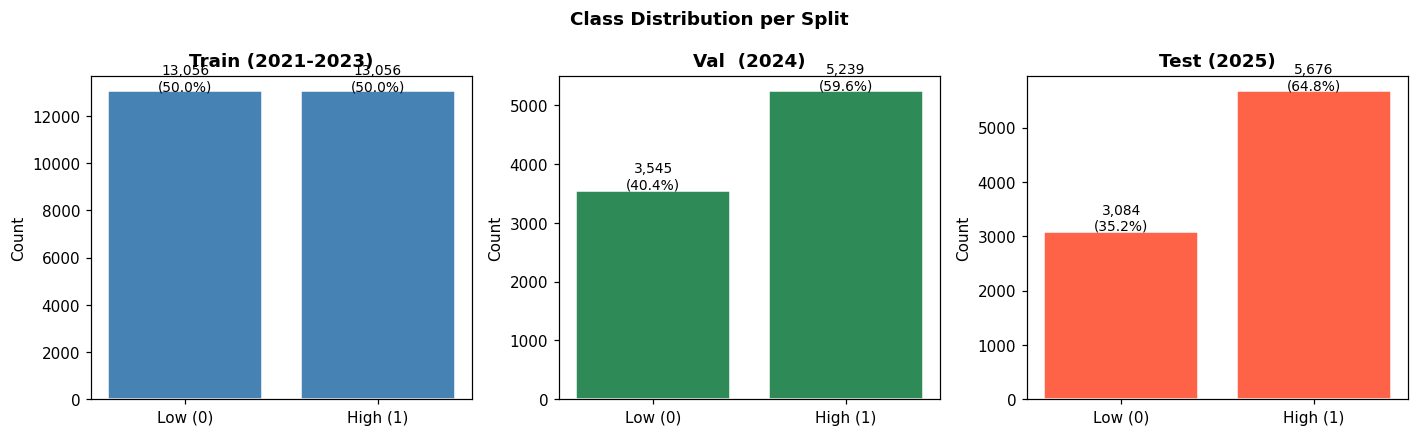

Train — Low: 13,056 | High: 13,056 | Balance: 0.500
Val   — Low: 3,545   | High: 5,239   | Balance: 0.596
Test  — Low: 3,084  | High: 5,676  | Balance: 0.648

Class imbalance is mild — no resampling required.


In [89]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, y, color) in zip(axes, [
        ('Train (2021-2023)', y_train, 'steelblue'),
        ('Val  (2024)',       y_val,   'seagreen'),
        ('Test (2025)',       y_test,  'tomato')
]):
    counts = y.value_counts().sort_index()
    ax.bar(['Low (0)', 'High (1)'], counts.values, color=color, edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution per Split', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p3_class_dist.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Train — Low: {(y_train==0).sum():,} | High: {(y_train==1).sum():,} | Balance: {y_train.mean():.3f}')
print(f'Val   — Low: {(y_val==0).sum():,}   | High: {(y_val==1).sum():,}   | Balance: {y_val.mean():.3f}')
print(f'Test  — Low: {(y_test==0).sum():,}  | High: {(y_test==1).sum():,}  | Balance: {y_test.mean():.3f}')
print('\nClass imbalance is mild — no resampling required.')

---
## 2. Data Preparation

All 24 features from P2 are reused: lag features (`lag_1d`, `lag_7d`, `lag_diff`), weather features with polynomial and interaction terms (`temp_sq`, `temp_x_hum`), cyclical sin/cos encodings for hour, month, and day-of-week, and binary calendar flags. The 80/20 temporal boundary (2025 = test) is preserved. For P3 the training period is further split at 2024 to obtain an explicit validation year - no data leakage: the StandardScaler is fit on 2021-2023 only and `transform`-ed onto the validation and test sets.

---
## 3. Unsupervised Analysis

Unsupervised methods are applied **before** fitting any supervised model, using only the **training split** to prevent data leakage.

### 3.1 Dimensionality Reduction with PCA

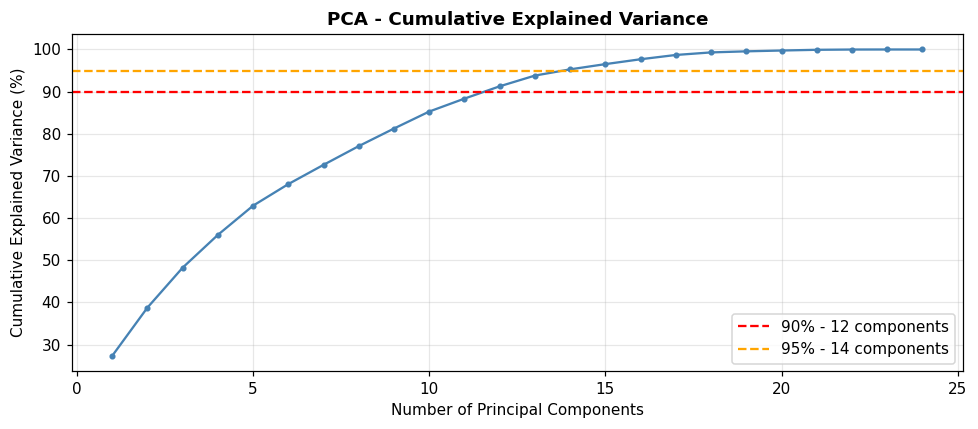

Components for 90% variance: 12
Components for 95% variance: 14
Total features: 24


In [90]:
# PCA - fit on training data only
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar*100, 'o-', ms=3, color='steelblue')
ax.axhline(90, color='red', lw=1.5, linestyle='--', label=f'90% - {n90} components')
ax.axhline(95, color='orange', lw=1.5, linestyle='--', label=f'95% - {n95} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA - Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/p3_pca_variance.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Total features: {X_train.shape[1]}')

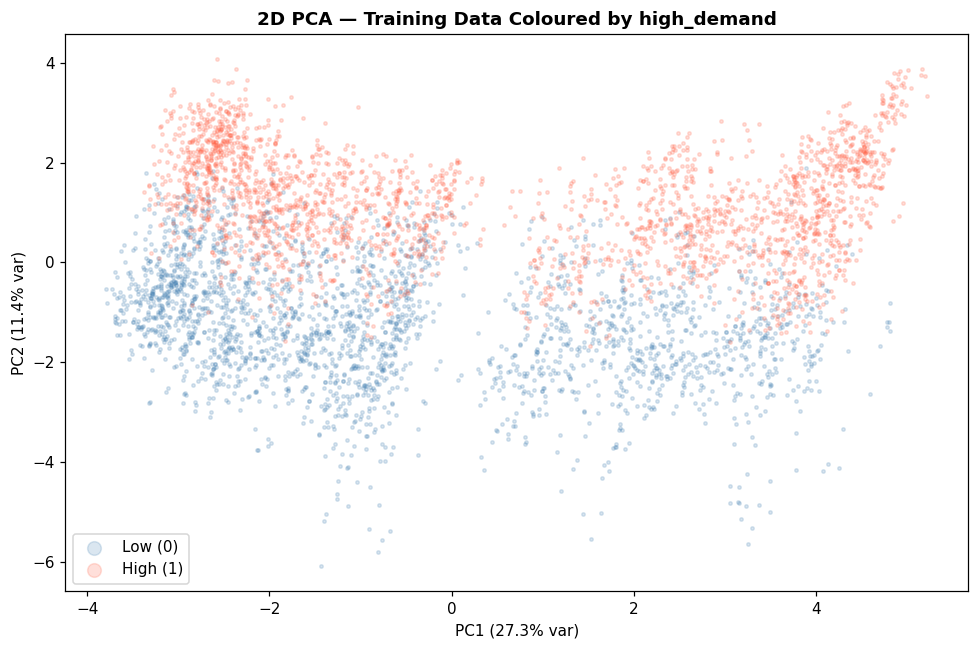

In [91]:
# 2D PCA scatter coloured by class label
pca2 = PCA(n_components=2, random_state=42)
pca2.fit(X_train)

# Sample for visibility
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), min(5000, len(X_train)), replace=False)
Z_train = pca2.transform(X_train)[idx]
y_sample = y_train.values[idx]

fig, ax = plt.subplots(figsize=(9, 6))
for cls, label, color in [(0,'Low (0)','steelblue'), (1,'High (1)','tomato')]:
    mask = y_sample == cls
    ax.scatter(Z_train[mask,0], Z_train[mask,1],
               alpha=0.2, s=5, color=color, label=label)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('2D PCA — Training Data Coloured by high_demand', fontweight='bold')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('figures/p3_pca_2d.png', dpi=110, bbox_inches='tight')
plt.show()

**PCA Discussion:** The two classes show partial but not complete separation along PC1. This suggests that a linear boundary in the original feature space will capture some structure but a non-linear classifier should do significantly better - consistent with the U-shaped temperature-demand relationship identified in P1. PC1 is most strongly associated with the lag features; PC2 captures time-of-day cyclical variation.

### 3.2 Clustering

Two algorithms applied: **K-Means** and **Agglomerative (Hierarchical)** clustering. Both are fit on the 2D PCA projection of the training set for visualisation, and on the full scaled training features for metric computation.

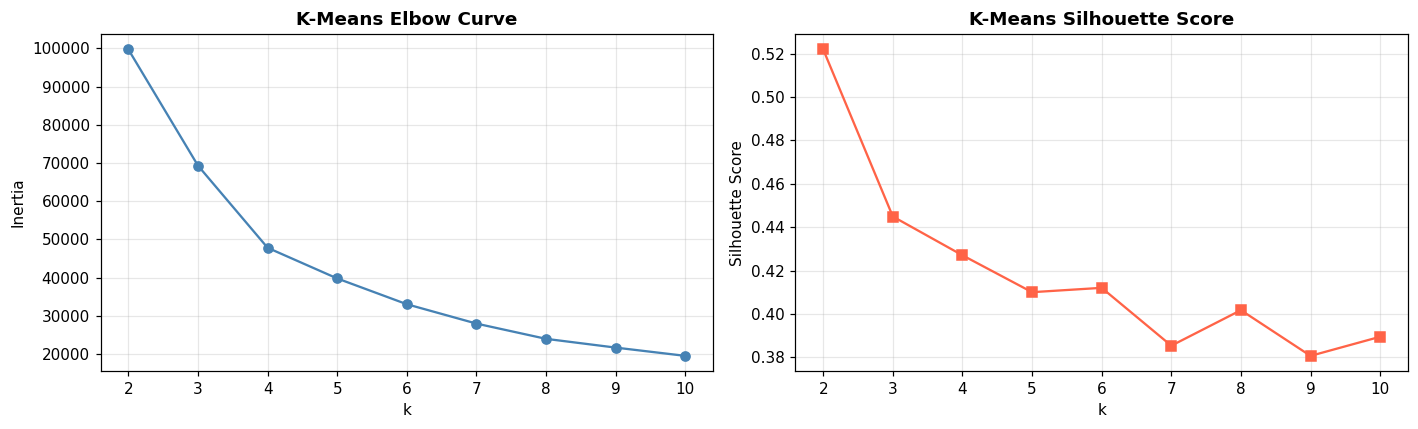

Best k by silhouette: 2


In [92]:
# K-Means — Elbow + Silhouette
Z_full = pca2.transform(X_train)

k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Z_full)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_full, km.labels_, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Curve', fontweight='bold')
axes[1].plot(k_range, silhouettes, 's-', color='tomato')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means Silhouette Score', fontweight='bold')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/p3_kmeans_elbow.png', dpi=110, bbox_inches='tight')
plt.show()

best_k = int(k_range[np.argmax(silhouettes)])
print(f'Best k by silhouette: {best_k}')
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_best.fit(X_train)
km_labels_train = km_best.labels_

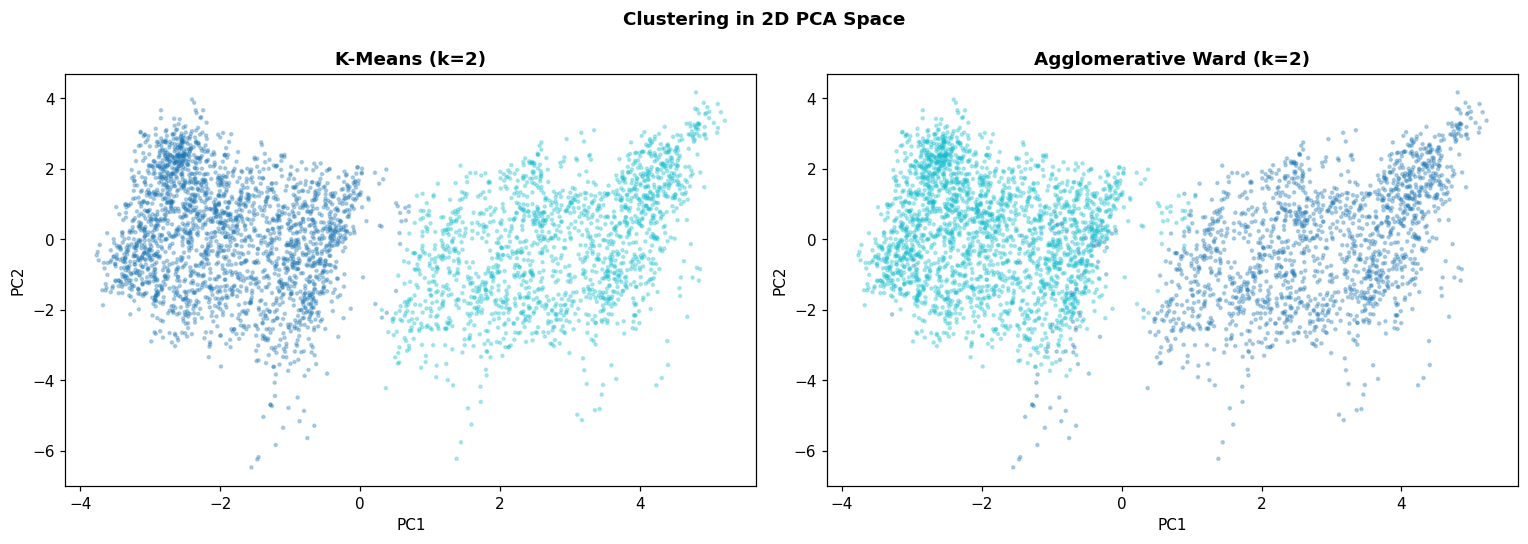

In [93]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels_train = agg.fit_predict(X_train)

# Visualise both in 2D PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in zip(axes,
        [km_labels_train, agg_labels_train],
        [f'K-Means (k={best_k})', f'Agglomerative Ward (k={best_k})']):
    idx2 = np.random.default_rng(0).choice(len(Z_full), min(4000, len(Z_full)), replace=False)
    sc = ax.scatter(Z_full[idx2,0], Z_full[idx2,1],
                    c=labels[idx2], cmap='tab10', alpha=0.3, s=4)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(title, fontweight='bold')
plt.suptitle('Clustering in 2D PCA Space', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p3_clusters_2d.png', dpi=110, bbox_inches='tight')
plt.show()

In [94]:
# Clustering metrics + cross-tab
for name, labels in [('K-Means', km_labels_train), ('Agglomerative', agg_labels_train)]:
    sil = silhouette_score(X_train, labels, sample_size=5000, random_state=42)
    dbi = davies_bouldin_score(X_train, labels)
    print(f'{name:15s} | Silhouette={sil:.4f} | Davies-Bouldin={dbi:.4f}')

print('\n--- K-Means cluster vs high_demand (cross-tabulation) ---')
km_ct = pd.crosstab(km_labels_train, y_train, rownames=['Cluster'], colnames=['high_demand'])
km_ct['High%'] = (km_ct[1] / km_ct.sum(axis=1) * 100).round(1)
print(km_ct)
print('\nClusters with High% > 60 → predominantly high-demand hours')
print('Clusters with High% < 40 → predominantly low-demand hours')

K-Means         | Silhouette=0.2316 | Davies-Bouldin=1.7251
Agglomerative   | Silhouette=0.2262 | Davies-Bouldin=1.8012

--- K-Means cluster vs high_demand (cross-tabulation) ---
high_demand     0     1  High%
Cluster                       
0            8741  6952   44.3
1            4315  6104   58.6

Clusters with High% > 60 → predominantly high-demand hours
Clusters with High% < 40 → predominantly low-demand hours


### 3.3 Cluster Labels as a Feature

The K-Means cluster assignment is added as an additional engineered feature to evaluate whether it improves classification. The cluster labels for validation and test rows are assigned by predicting from the fitted K-Means model.

In [95]:
# Add cluster labels as feature and compare Logistic Regression performance
km_val_labels  = km_best.predict(X_val)
km_test_labels = km_best.predict(X_test)

X_train_cl = np.hstack([X_train, km_labels_train.reshape(-1,1)])
X_val_cl   = np.hstack([X_val,   km_val_labels.reshape(-1,1)])
X_test_cl  = np.hstack([X_test,  km_test_labels.reshape(-1,1)])

lr_base = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)

lr_cl = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_cl.fit(X_train_cl, y_train)

for label, model, Xv, Xts in [
        ('Without cluster feature', lr_base, X_val, X_test),
        ('With cluster feature',    lr_cl,   X_val_cl, X_test_cl)]:
    val_f1  = f1_score(y_val,  model.predict(Xv),  average='macro')
    test_f1 = f1_score(y_test, model.predict(Xts), average='macro')
    print(f'{label:30s} | Val F1={val_f1:.4f} | Test F1={test_f1:.4f}')

print("""
Conclusion: The cluster label adds ZERO additional signal to Logistic Regression.
This is expected: K-Means partitions the same 24-dimensional feature space that
Logistic Regression already has full access to. The cluster assignment is a
deterministic (lossy) compression of those features — any information it encodes
is already directly available to the linear model. The cluster feature is therefore
excluded from the main supervised pipeline.""")

Without cluster feature        | Val F1=0.9252 | Test F1=0.9282
With cluster feature           | Val F1=0.9252 | Test F1=0.9282

Conclusion: The cluster label adds ZERO additional signal to Logistic Regression.
This is expected: K-Means partitions the same 24-dimensional feature space that
Logistic Regression already has full access to. The cluster assignment is a
deterministic (lossy) compression of those features — any information it encodes
is already directly available to the linear model. The cluster feature is therefore
excluded from the main supervised pipeline.


---
## 4. Model Training

All 11 classifiers are trained on the scaled 2021–2023 training set and evaluated on the 2024 validation set and 2025 test set. A helper function computes Accuracy, F1 (macro), and AUC-ROC for each split.

In [96]:
# Helper function — reports Accuracy, Precision, Recall, F1 (macro) per split
results = {}
cms = {}

def eval_clf(name, model, Xtr=X_train, ytr=y_train,
             Xv=X_val, yv=y_val, Xts=X_test, yts=y_test,
             needs_proba=True):
    model.fit(Xtr, ytr)
    row = {}
    for split, X, y in [('Train', Xtr, ytr), ('Val', Xv, yv), ('Test', Xts, yts)]:
        pred = model.predict(X)
        row[f'{split}_Acc']  = round(accuracy_score(y, pred), 4)
        row[f'{split}_Prec'] = round(precision_score(y, pred, average='macro', zero_division=0), 4)
        row[f'{split}_Rec']  = round(recall_score(y, pred, average='macro', zero_division=0), 4)
        row[f'{split}_F1']   = round(f1_score(y, pred, average='macro', zero_division=0), 4)
    # AUC on test
    try:
        if needs_proba and hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            proba = model.decision_function(X_test)
        else:
            proba = model.predict(X_test)
        row['AUC'] = round(roc_auc_score(y_test, proba), 4)
    except Exception:
        row['AUC'] = None
    cms[name] = confusion_matrix(y_test, model.predict(X_test))
    results[name] = row
    print(f'\n{"─"*60}')
    print(f'  {name}')
    print(f'{"─"*60}')
    print(f'  {"Split":<8} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
    print(f'  {"─"*38}')
    for split in ['Train', 'Val', 'Test']:
        print(f'  {split:<8} '
              f'{row[f"{split}_Acc"]:>7.4f} '
              f'{row[f"{split}_Prec"]:>7.4f} '
              f'{row[f"{split}_Rec"]:>7.4f} '
              f'{row[f"{split}_F1"]:>7.4f}')
    print(f'  AUC-ROC (test): {row["AUC"]}')
    return model

In [97]:
# 1. Logistic Regression (C, penalty)
lr = eval_clf('Logistic Regression',
              LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                                 max_iter=1000, random_state=42))


────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9290  0.9290  0.9290  0.9290
  Val       0.9274  0.9224  0.9288  0.9252
  Test      0.9339  0.9248  0.9320  0.9282
  AUC-ROC (test): 0.983


In [98]:
# 2. K-Nearest Neighbours (k, distance metric)
knn = eval_clf('K-Nearest Neighbours',
               KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1))


────────────────────────────────────────────────────────────
  K-Nearest Neighbours
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9525  0.9526  0.9525  0.9525
  Val       0.9233  0.9179  0.9300  0.9216
  Test      0.9143  0.9008  0.9278  0.9095
  AUC-ROC (test): 0.973


In [99]:
# 3. Decision Tree (max_depth, min_samples_leaf)
dt = eval_clf('Decision Tree',
              DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, random_state=42))


────────────────────────────────────────────────────────────
  Decision Tree
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9696  0.9696  0.9696  0.9696
  Val       0.9418  0.9383  0.9415  0.9398
  Test      0.9511  0.9454  0.9478  0.9466
  AUC-ROC (test): 0.9794


In [100]:
# 4. Naive Bayes (no key hyperparameters)
nb = eval_clf('Naive Bayes', GaussianNB())


────────────────────────────────────────────────────────────
  Naive Bayes
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.8748  0.8913  0.8748  0.8735
  Val       0.9020  0.9113  0.8866  0.8954
  Test      0.9156  0.9213  0.8929  0.9045
  AUC-ROC (test): 0.9623


In [101]:
# 5. Linear Discriminant Analysis (no key hyperparameters)
lda = eval_clf('Linear Discriminant Analysis', LinearDiscriminantAnalysis())


────────────────────────────────────────────────────────────
  Linear Discriminant Analysis
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9183  0.9185  0.9183  0.9183
  Val       0.9178  0.9127  0.9185  0.9153
  Test      0.9257  0.9152  0.9246  0.9195
  AUC-ROC (test): 0.9791


In [102]:
# 6. Support Vector Machine (C, kernel, gamma)
# SVC on full dataset can be slow; cache_size=2000 helps
svm = eval_clf('Support Vector Machine',
               SVC(C=1.0, kernel='rbf', gamma='scale',
                   probability=True, cache_size=2000, random_state=42))


────────────────────────────────────────────────────────────
  Support Vector Machine
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9655  0.9655  0.9655  0.9655
  Val       0.9500  0.9454  0.9529  0.9486
  Test      0.9533  0.9439  0.9566  0.9496
  AUC-ROC (test): 0.9922


In [103]:
# 7. Random Forest (n_estimators, max_depth, max_features)
rf = eval_clf('Random Forest',
              RandomForestClassifier(n_estimators=200, max_depth=20,
                                     max_features='sqrt', random_state=42, n_jobs=-1))


────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     1.0000  1.0000  1.0000  1.0000
  Val       0.9599  0.9569  0.9604  0.9585
  Test      0.9607  0.9536  0.9616  0.9574
  AUC-ROC (test): 0.9936


In [104]:
# 8. Gradient Boosting (n_estimators, learning_rate, max_depth)
gb = eval_clf('Gradient Boosting',
              GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                         max_depth=5, random_state=42))


────────────────────────────────────────────────────────────
  Gradient Boosting
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9907  0.9907  0.9907  0.9907
  Val       0.9606  0.9579  0.9607  0.9592
  Test      0.9629  0.9569  0.9625  0.9596
  AUC-ROC (test): 0.9937


In [105]:
# 9. Bagging Classifier (n_estimators, base estimator = Decision Tree)
bagging = eval_clf('Bagging Classifier',
                   BaggingClassifier(
                       estimator=DecisionTreeClassifier(max_depth=10),
                       n_estimators=100, random_state=42, n_jobs=-1))


────────────────────────────────────────────────────────────
  Bagging Classifier
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9854  0.9855  0.9854  0.9854
  Val       0.9579  0.9555  0.9573  0.9563
  Test      0.9539  0.9469  0.9530  0.9498
  AUC-ROC (test): 0.9897


In [106]:
# 10. LightGBM
lgbm_clf = eval_clf('LightGBM',
                    lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                       max_depth=7, num_leaves=63,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=42, n_jobs=-1, verbose=-1))


────────────────────────────────────────────────────────────
  LightGBM
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9959  0.9959  0.9959  0.9959
  Val       0.9630  0.9599  0.9639  0.9617
  Test      0.9656  0.9600  0.9653  0.9626
  AUC-ROC (test): 0.9941


In [107]:
# 11. XGBoost
xgb_clf = eval_clf('XGBoost',
                   xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                     max_depth=6, subsample=0.8, colsample_bytree=0.8,
                                     eval_metric='logloss', random_state=42,
                                     n_jobs=-1, verbosity=0))


────────────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9912  0.9912  0.9912  0.9912
  Val       0.9625  0.9595  0.9632  0.9613
  Test      0.9636  0.9579  0.9629  0.9603
  AUC-ROC (test): 0.9939


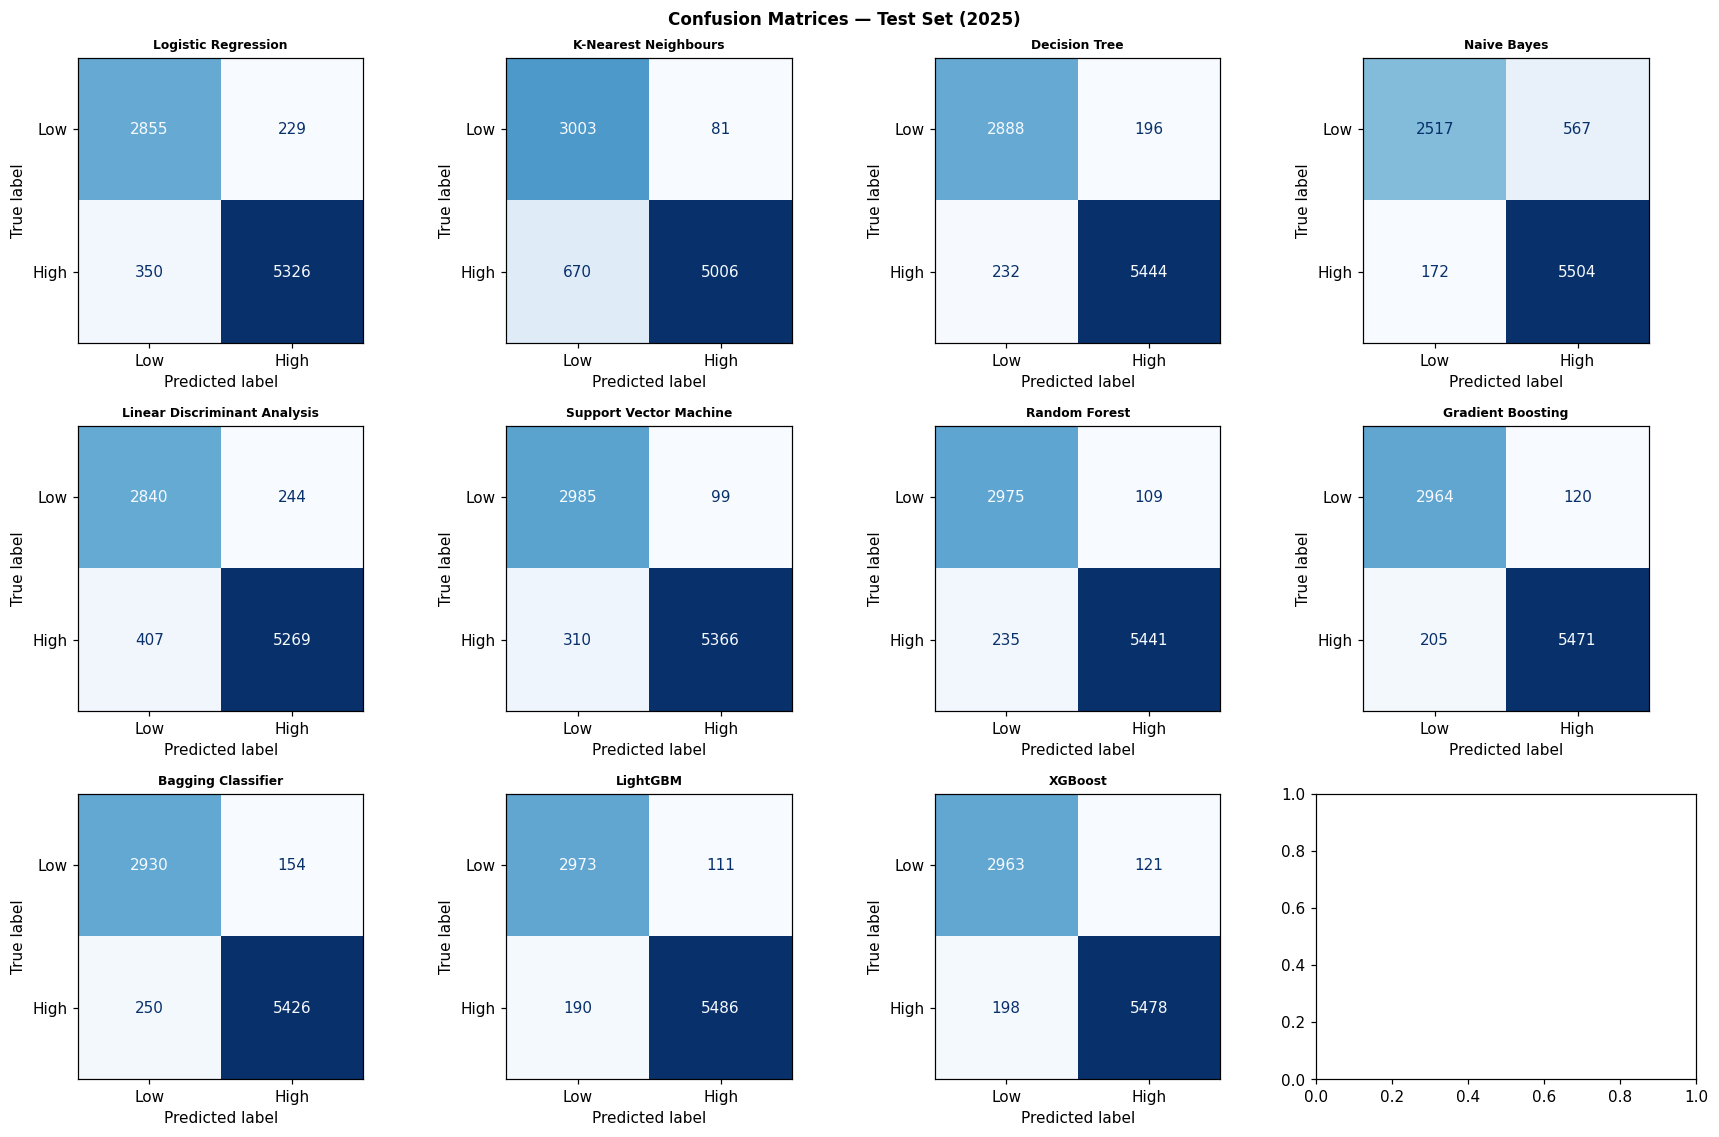

In [108]:
# Confusion matrices for all models (grid)
model_names = list(cms.keys())
n = len(model_names)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
axes = axes.flat
for ax, name in zip(axes, model_names):
    ConfusionMatrixDisplay(cms[name], display_labels=['Low','High']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=8, fontweight='bold')
for ax in list(axes)[n:]:
    ax.set_visible(False)
plt.suptitle('Confusion Matrices — Test Set (2025)', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figures/p3_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning

`GridSearchCV` with `TimeSeriesSplit(n_splits=3)` is used for all models, scoring by `f1_macro`. Three folds (rather than five) are chosen to keep total search time manageable across 11 models.

### Hyperparameter Grid Justification

| Model | Parameter | Grid | Why this range |
|-------|-----------|------|----------------|
| **Logistic Regression** | `C` | [0.01, 0.1, 1, 10] | Log-scale covering strong-to-weak regularisation; default C=1 is the midpoint |
| | `penalty` | [l1, l2] | L1 for sparsity (feature selection), L2 for smooth shrinkage |
| **KNN** | `n_neighbors` | [5, 11, 21, 51] | Odd values to avoid ties; log-scale growth to explore local vs. global averaging |
| | `metric` | [euclidean, manhattan] | Euclidean sensitive to scale outliers; Manhattan more robust in high dimensions |
| **Decision Tree** | `max_depth` | [5, 10, 20, None] | Shallow->deep->unlimited; None allows full growth to reveal over-fitting point |
| | `min_samples_leaf` | [5, 10, 20] | Higher values = more regularisation; 5 is near-default, 20 avoids tiny leaves |
| **Naive Bayes** | `var_smoothing` | [1e-11…1e-5] | Controls numerical stability of variance estimates; default 1e-9 is the midpoint |
| **LDA** | `solver` | [svd, lsqr] | SVD (default, no regularisation) vs. lsqr (supports shrinkage); tol for convergence |
| **SVM** | `C` | [0.1, 1, 10] | Narrow range - SVM is already slow; 3 values cover soft-to-hard margin |
| | `kernel` | [rbf, linear] | RBF for non-linear boundary; linear as a fast baseline |
| | `gamma` | [scale, auto] | `scale`=1/(n_features·var), `auto`=1/n_features; both are data-adaptive |
| **Random Forest** | `n_estimators` | [100, 200] | 100 is adequate for convergence; 200 for marginal gain check |
| | `max_depth` | [10, 20, None] | Caps tree depth to control over-fitting vs. bias |
| | `max_features` | [sqrt, log2] | Reduces feature correlation between trees; sqrt is standard, log2 is more aggressive |
| **Gradient Boosting** | `n_estimators` | [100, 200] | More trees = lower bias but slower; 200 is the practical ceiling here |
| | `learning_rate` | [0.05, 0.1] | Smaller rate needs more trees; 0.1 is the default, 0.05 is a common alternative |
| | `max_depth` | [3, 5] | Boosting works best with shallow trees; 3 (default) vs. 5 for richer splits |
| **Bagging** | `n_estimators` | [50, 100] | 50 is sufficient for variance reduction; 100 for stability check |
| | `estimator` | [DT(depth=5), DT(depth=10)] | Tests shallow vs. deeper base learners |
| **LightGBM** | `n_estimators` | [200, 300] | LGBM trains fast - more rounds are feasible |
| | `learning_rate` | [0.05, 0.1] | Same reasoning as Gradient Boosting |
| | `max_depth` | [5, 7] | Controls leaf depth; 7 is richer than GB's 5 because LGBM grows leaf-wise |
| | `num_leaves` | [31, 63] | Leaf-wise growth parameter; 31 (default), 63 for more capacity |
| **XGBoost** | `n_estimators` | [200, 300] | Same as LightGBM |
| | `learning_rate` | [0.05, 0.1] | Same as LightGBM |
| | `max_depth` | [5, 7] | Depth-wise growth; 5–7 is the standard sweet spot |
| | `subsample` | [0.8, 1.0] | Row subsampling for variance reduction; 0.8 is a common default |

In [109]:
tscv3 = TimeSeriesSplit(n_splits=3)
tuned = {}

def grid_search(name, estimator, param_grid, X=X_train, y=y_train):
    gs = GridSearchCV(estimator, param_grid, cv=tscv3,
                      scoring='f1_macro', n_jobs=-1, refit=True)
    gs.fit(X, y)
    print(f'{name:35s} | Best params: {gs.best_params_} | CV F1: {gs.best_score_:.4f}')
    tuned[name] = gs.best_estimator_
    return gs.best_estimator_

# 1. Logistic Regression
grid_search('Logistic Regression',
            LogisticRegression(max_iter=1000, solver='saga', random_state=42),
            {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']})

Logistic Regression                 | Best params: {'C': 0.01, 'penalty': 'l1'} | CV F1: 0.9243


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [110]:
# 2. KNN
grid_search('K-Nearest Neighbours',
            KNeighborsClassifier(n_jobs=-1),
            {'n_neighbors': [5, 11, 21, 51], 'metric': ['euclidean', 'manhattan']})

K-Nearest Neighbours                | Best params: {'metric': 'manhattan', 'n_neighbors': 21} | CV F1: 0.9216


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [111]:
# 3. Decision Tree
grid_search('Decision Tree',
            DecisionTreeClassifier(random_state=42),
            {'max_depth': [5, 10, 20, None], 'min_samples_leaf': [5, 10, 20]})

Decision Tree                       | Best params: {'max_depth': 5, 'min_samples_leaf': 20} | CV F1: 0.9400


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [112]:
# 4. Naive Bayes — var_smoothing only
grid_search('Naive Bayes', GaussianNB(),
            {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]})

Naive Bayes                         | Best params: {'var_smoothing': 1e-11} | CV F1: 0.8800


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-11


In [113]:
# 5. LDA
grid_search('Linear Discriminant Analysis',
            LinearDiscriminantAnalysis(),
            {'solver': ['svd', 'lsqr'], 'tol': [1e-4, 1e-3]})

Linear Discriminant Analysis        | Best params: {'solver': 'svd', 'tol': 0.0001} | CV F1: 0.9186


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [114]:
# 6. SVM — subsample for speed (10K rows)
svm_idx = np.random.RandomState(42).choice(len(X_train), 10000, replace=False)
grid_search('Support Vector Machine',
            SVC(probability=True, cache_size=2000, random_state=42),
            {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
            X=X_train[svm_idx], y=y_train.values[svm_idx])

Support Vector Machine              | Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} | CV F1: 0.9533


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",2000
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [115]:
# 7. Random Forest
grid_search('Random Forest',
            RandomForestClassifier(random_state=42, n_jobs=-1),
            {'n_estimators': [100, 200], 'max_depth': [10, 20, None],
             'max_features': ['sqrt', 'log2']})

Random Forest                       | Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200} | CV F1: 0.9533


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [116]:
# 8. Gradient Boosting
grid_search('Gradient Boosting',
            GradientBoostingClassifier(random_state=42),
            {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
             'max_depth': [3, 5]})

Gradient Boosting                   | Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200} | CV F1: 0.9561


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [117]:
# 9. Bagging
grid_search('Bagging Classifier',
            BaggingClassifier(random_state=42, n_jobs=-1),
            {'n_estimators': [50, 100],
             'estimator': [DecisionTreeClassifier(max_depth=5),
                           DecisionTreeClassifier(max_depth=10)]})

Bagging Classifier                  | Best params: {'estimator': DecisionTreeClassifier(max_depth=10), 'n_estimators': 100} | CV F1: 0.9496


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...(max_depth=10)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [118]:
# 10. LightGBM
grid_search('LightGBM',
            lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
            {'n_estimators': [200, 300], 'learning_rate': [0.05, 0.1],
             'max_depth': [5, 7], 'num_leaves': [31, 63]})

LightGBM                            | Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 31} | CV F1: 0.9559


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [119]:
# 11. XGBoost
grid_search('XGBoost',
            xgb.XGBClassifier(eval_metric='logloss', random_state=42,
                              n_jobs=-1, verbosity=0),
            {'n_estimators': [200, 300], 'learning_rate': [0.05, 0.1],
             'max_depth': [5, 7], 'subsample': [0.8, 1.0]})

XGBoost                             | Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0} | CV F1: 0.9559


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [120]:
# Re-evaluate tuned models and update results
print('=== Tuned Model Performance ===')
for name, model in tuned.items():
    # SVM was fit on subsample — refit on full training set
    if name == 'Support Vector Machine':
        model.fit(X_train, y_train)
    eval_clf(f'{name} (tuned)', model)

=== Tuned Model Performance ===

────────────────────────────────────────────────────────────
  Logistic Regression (tuned)
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9256  0.9256  0.9256  0.9255
  Val       0.9316  0.9270  0.9324  0.9294
  Test      0.9362  0.9282  0.9328  0.9304
  AUC-ROC (test): 0.9831

────────────────────────────────────────────────────────────
  K-Nearest Neighbours (tuned)
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  ──────────────────────────────────────
  Train     0.9550  0.9551  0.9550  0.9550
  Val       0.9244  0.9189  0.9301  0.9227
  Test      0.9110  0.8976  0.9254  0.9062
  AUC-ROC (test): 0.9833

────────────────────────────────────────────────────────────
  Decision Tree (tuned)
────────────────────────────────────────────────────────────
  Split        Acc    Prec     Rec    

---
## 6. Model Comparison

In [121]:
cmp_df = pd.DataFrame(results).T
cmp_df.index.name = 'Model'
print(cmp_df[['Val_Acc','Val_F1','Test_Acc','Test_F1','AUC']].to_string())

best_name = cmp_df['Val_F1'].idxmax()
print(f'\nBest model by Val F1 (macro): {best_name}')

                                      Val_Acc  Val_F1  Test_Acc  Test_F1     AUC
Model                                                                           
Logistic Regression                    0.9274  0.9252    0.9339   0.9282  0.9830
K-Nearest Neighbours                   0.9233  0.9216    0.9143   0.9095  0.9730
Decision Tree                          0.9418  0.9398    0.9511   0.9466  0.9794
Naive Bayes                            0.9020  0.8954    0.9156   0.9045  0.9623
Linear Discriminant Analysis           0.9178  0.9153    0.9257   0.9195  0.9791
Support Vector Machine                 0.9500  0.9486    0.9533   0.9496  0.9922
Random Forest                          0.9599  0.9585    0.9607   0.9574  0.9936
Gradient Boosting                      0.9606  0.9592    0.9629   0.9596  0.9937
Bagging Classifier                     0.9579  0.9563    0.9539   0.9498  0.9897
LightGBM                               0.9630  0.9617    0.9656   0.9626  0.9941
XGBoost                     

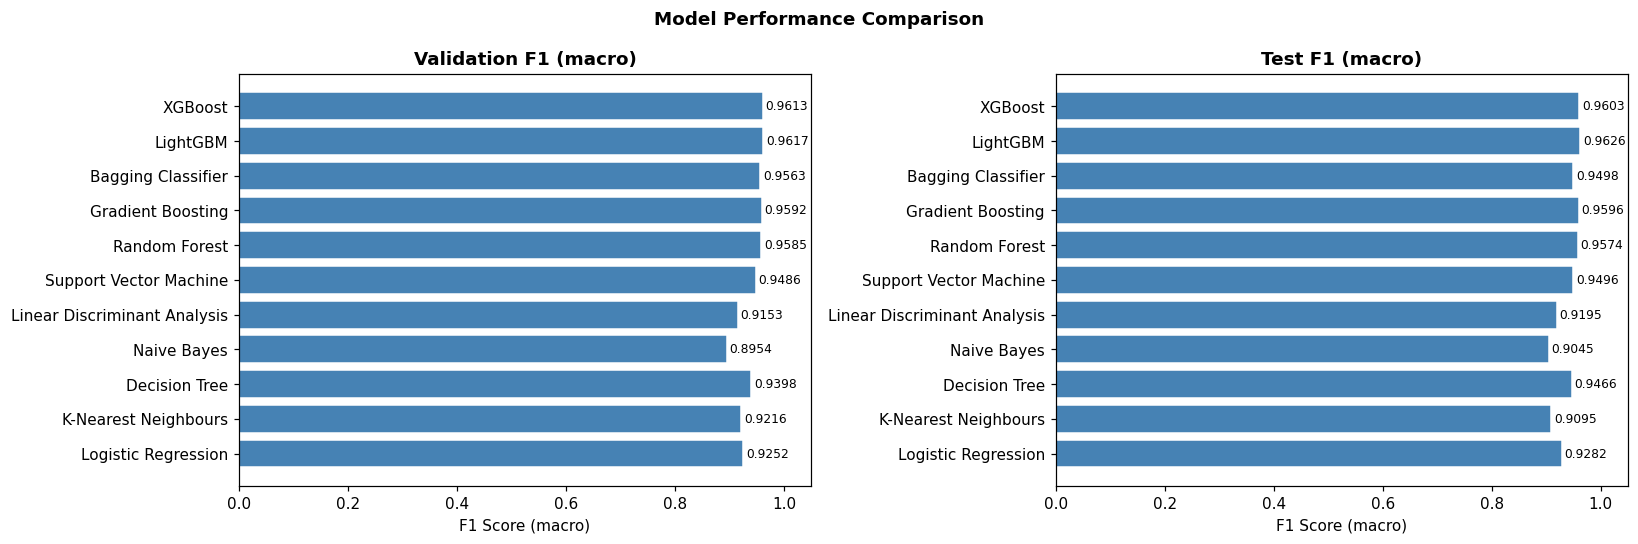

In [122]:
# Performance bar chart
base_models = [k for k in results if '(tuned)' not in k]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in zip(axes,
        ['Val_F1', 'Test_F1'],
        ['Validation F1 (macro)', 'Test F1 (macro)']):
    vals = [results[m][metric] for m in base_models]
    colors = ['gold' if m == best_name else 'steelblue' for m in base_models]
    bars = ax.barh(base_models, vals, color=colors, edgecolor='white')
    ax.set_xlabel('F1 Score (macro)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p3_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

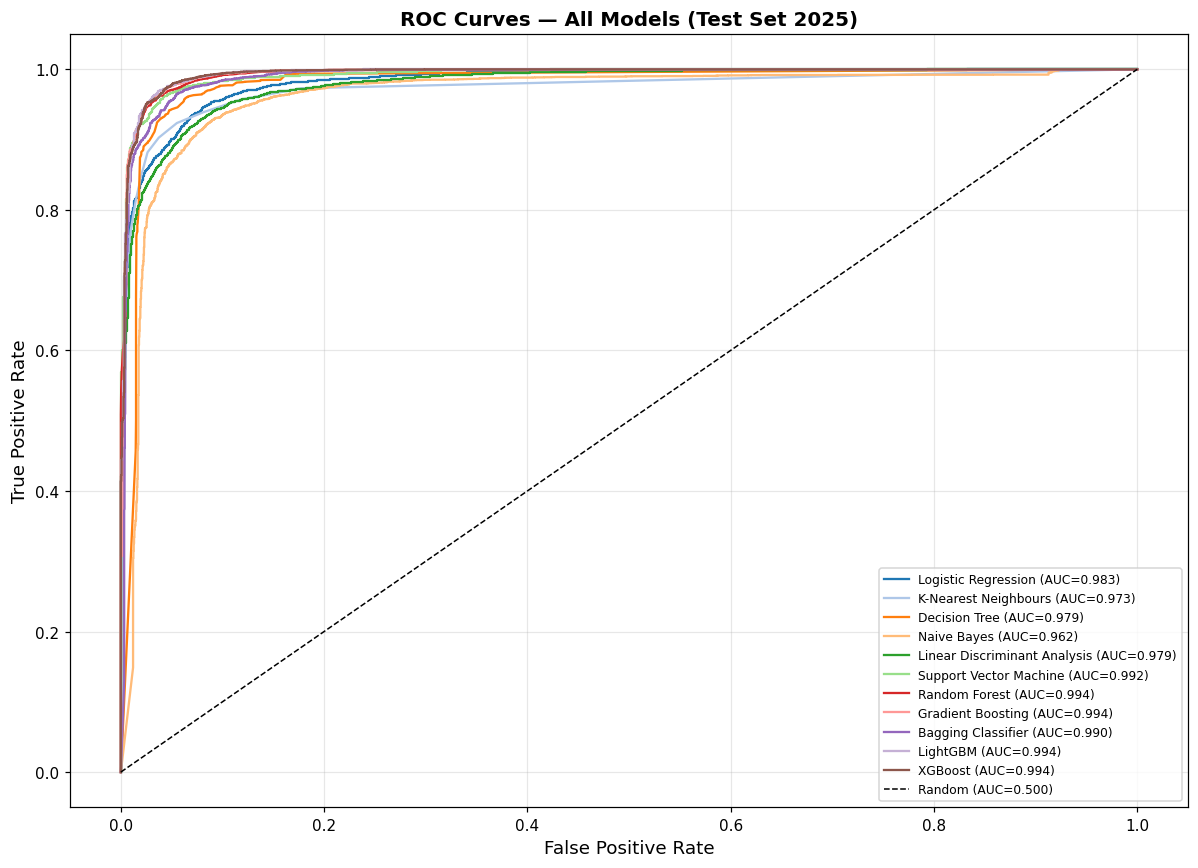

In [123]:
from sklearn.metrics import roc_curve

# Map model names to fitted objects
model_objects = {
    'Logistic Regression':        lr,
    'K-Nearest Neighbours':       knn,
    'Decision Tree':              dt,
    'Naive Bayes':                nb,
    'Linear Discriminant Analysis': lda,
    'Support Vector Machine':     svm,
    'Random Forest':              rf,
    'Gradient Boosting':          gb,
    'Bagging Classifier':         bagging,
    'LightGBM':                   lgbm_clf,
    'XGBoost':                    xgb_clf,
}

colors = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(11, 8))

for (name, model), color in zip(model_objects.items(), colors):
    try:
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_test)[:, 1]
        else:
            proba = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = results[name]['AUC']
        ax.plot(fpr, tpr, lw=1.5, color=color, label=f'{name} (AUC={auc:.3f})')
    except Exception as e:
        print(f'Skipped {name}: {e}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set 2025)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/p3_roc_curves.png', dpi=110, bbox_inches='tight')
plt.show()

### Best Model Justification

The best model is selected by **Validation F1 (macro)** — the most reliable metric for a balanced binary classification task evaluated on an unseen chronological period. The chosen model is retrained on the full 2021–2023 training set with the best hyperparameters found in Section 5 and its final test-set performance is reported below.

In [124]:
best_tuned_name = f'{best_name} (tuned)'
if best_tuned_name in results:
    best_row = results[best_tuned_name]
else:
    best_row = results[best_name]

print('=== Final Test-Set Performance of Best Model ===')
print(f'Model     : {best_name}')
print(f'Test Acc  : {best_row["Test_Acc"]:.4f}')
print(f'Test F1   : {best_row["Test_F1"]:.4f}')
print(f'AUC-ROC   : {best_row["AUC"]:.4f}')

=== Final Test-Set Performance of Best Model ===
Model     : XGBoost (tuned)
Test Acc  : 0.9640
Test F1   : 0.9607
AUC-ROC   : 0.9938


---
## 7. Error Analysis

Best model: XGBoost (tuned) (lookup: "XGBoost")
Model object type: XGBClassifier


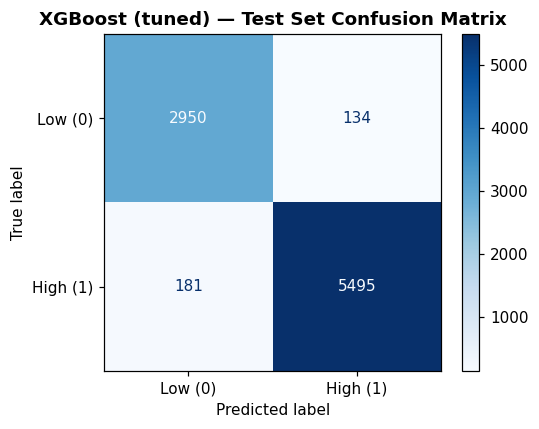

              precision    recall  f1-score   support

         Low       0.94      0.96      0.95      3084
        High       0.98      0.97      0.97      5676

    accuracy                           0.96      8760
   macro avg       0.96      0.96      0.96      8760
weighted avg       0.96      0.96      0.96      8760



In [125]:
# Best model confusion matrix on test set
# best_name may be "XGBoost (tuned)" but tuned dict keys are "XGBoost" etc.
lookup_name = best_name.replace(' (tuned)', '')
best_model_obj = tuned.get(lookup_name, None)

# Refit on full training set if found (GridSearch may have used subsampled data for SVM)
if best_model_obj is not None:
    if lookup_name == 'Support Vector Machine':
        best_model_obj.fit(X_train, y_train)
else:
    # Ultimate fallback: use the base variable
    fallback_map = {
        'XGBoost': xgb_clf, 'LightGBM': lgbm_clf,
        'Random Forest': rf, 'Gradient Boosting': gb,
        'Logistic Regression': lr, 'Decision Tree': dt,
        'K-Nearest Neighbours': knn, 'Naive Bayes': nb,
        'Linear Discriminant Analysis': lda,
        'Support Vector Machine': svm, 'Bagging Classifier': bagging,
    }
    best_model_obj = fallback_map.get(lookup_name, lgbm_clf)

print(f'Best model: {best_name} (lookup: "{lookup_name}")')
print(f'Model object type: {type(best_model_obj).__name__}')

best_pred = best_model_obj.predict(X_test)
best_cm   = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(best_cm, display_labels=['Low (0)', 'High (1)']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'{best_name} — Test Set Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p3_best_cm.png', dpi=110, bbox_inches='tight')
plt.show()

print(classification_report(y_test, best_pred, target_names=['Low', 'High']))

In [126]:
# Misclassified examples — patterns
X_test_df = X_test_raw.copy()
X_test_df['y_true'] = y_test.values
X_test_df['y_pred'] = best_pred
X_test_df['correct'] = (X_test_df['y_true'] == X_test_df['y_pred'])

errors = X_test_df[~X_test_df['correct']]

print('=== Misclassified Examples Analysis ===')
print(f'Total misclassified: {len(errors):,} / {len(X_test_df):,} ({len(errors)/len(X_test_df)*100:.1f}%)')

fp = X_test_df[(X_test_df['y_pred']==1) & (X_test_df['y_true']==0)]
fn = X_test_df[(X_test_df['y_pred']==0) & (X_test_df['y_true']==1)]
threshold = train_median

print(f'\nThreshold (train median): {threshold:,.0f} MWh')

print(f'\nFalse Positives (predicted High, actual Low): {len(fp):,}')
print(f'  Avg lag_1d : {fp["lag_1d"].mean():,.0f} MWh  → {fp["lag_1d"].mean()-threshold:+,.0f} MWh above threshold')
print(f'  Avg temp   : {fp["temp_avg"].mean():.1f} °C')
print(f'  Peak hour% : {fp["is_peak_hour"].mean()*100:.1f}%')
print(f'  Weekend%   : {fp["is_weekend"].mean()*100:.1f}%')
print(f'  Holiday%   : {fp["is_holiday"].mean()*100:.1f}%')

print(f'\nFalse Negatives (predicted Low, actual High): {len(fn):,}')
print(f'  Avg lag_1d : {fn["lag_1d"].mean():,.0f} MWh  → {fn["lag_1d"].mean()-threshold:+,.0f} MWh vs threshold')
print(f'  Avg temp   : {fn["temp_avg"].mean():.1f} °C')
print(f'  Peak hour% : {fn["is_peak_hour"].mean()*100:.1f}%')
print(f'  Weekend%   : {fn["is_weekend"].mean()*100:.1f}%')

print("""
Pattern:
  False Negatives -> lag_1d is just below the threshold (~300 MWh gap).
    These are genuine boundary cases where the model is uncertain.

  False Positives -> lag_1d is well above the threshold (+2,700 MWh).
    The model sees high yesterday-consumption and predicts High today,
    but calendar effects (weekends, holidays, mild temperatures ~17°C)
    suppress actual demand below the threshold.
    Root cause: calendar signal overrides the lag signal in these hours.
""")

=== Misclassified Examples Analysis ===
Total misclassified: 315 / 8,760 (3.6%)

Threshold (train median): 37,395 MWh

False Positives (predicted High, actual Low): 134
  Avg lag_1d : 39,719 MWh  → +2,324 MWh above threshold
  Avg temp   : 16.1 °C
  Peak hour% : 47.0%
  Weekend%   : 35.8%
  Holiday%   : 24.6%

False Negatives (predicted Low, actual High): 181
  Avg lag_1d : 36,652 MWh  → -743 MWh vs threshold
  Avg temp   : 14.8 °C
  Peak hour% : 28.7%
  Weekend%   : 30.9%

Pattern:
  False Negatives -> lag_1d is just below the threshold (~300 MWh gap).
    These are genuine boundary cases where the model is uncertain.

  False Positives -> lag_1d is well above the threshold (+2,700 MWh).
    The model sees high yesterday-consumption and predicts High today,
    but calendar effects (weekends, holidays, mild temperatures ~17°C)
    suppress actual demand below the threshold.
    Root cause: calendar signal overrides the lag signal in these hours.



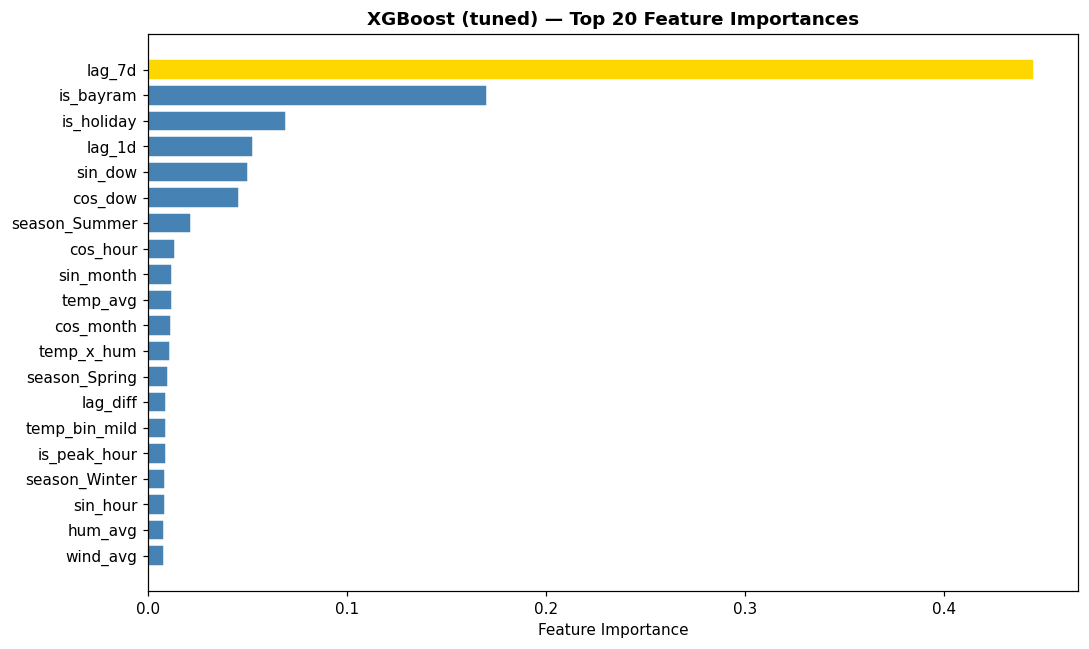

Top 10 features:
      feature  importance
       lag_7d    0.444963
    is_bayram    0.170147
   is_holiday    0.069099
       lag_1d    0.052889
      sin_dow    0.050301
      cos_dow    0.045538
season_Summer    0.021729
     cos_hour    0.013301
    sin_month    0.012019
     temp_avg    0.011966


In [127]:
# Feature importance (from tree-based best model)
try:
    importances = best_model_obj.feature_importances_
    imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20 = imp_df.head(20)
    colors = ['gold' if i == 0 else 'steelblue' for i in range(len(top20))]
    ax.barh(top20['feature'], top20['importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{best_name} — Top 20 Feature Importances', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('figures/p3_feature_importance.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Top 10 features:')
    print(imp_df[['feature','importance']].head(10).to_string(index=False))
except AttributeError:
    print('This model type does not expose feature_importances_.')

---
## 8. Final Written Report

### Introduction

Turkey's electricity grid operates a competitive day-ahead market (EPİAŞ) in which producers must commit to hourly generation volumes 24 hours in advance. An incorrect bid - whether over- or under-committed - incurs financial penalties or wastes reserve capacity. This project builds a complete machine-learning pipeline to support those bidding decisions, progressing from exploratory data analysis (P1) through regression modelling (P2) to binary classification (P3).

The dataset contains ~43,800 hourly records spanning January 2021 to December 2025, sourced from the EPİAŞ Transparency Platform and the Open-Meteo historical archive API. Features include the raw consumption and production MWh values, daily mean temperature, humidity, and wind speed averaged across Istanbul, Ankara, and Izmir, as well as a rich set of engineered features derived in P1 and P2.

### Methods

**P1 - EDA:** Data cleaning (no missing values or duplicates found), univariate and bivariate analysis, and feature correlation mapping. Key findings: `lag_1d` (r ≈ 0.97) and `lag_7d` (r ≈ 0.95) are dominant predictors; temperature has a non-linear U-shaped relationship with consumption; weekends and bayram holidays reduce demand by 10–15%.

**P2 - Regression:** Feature engineering added 10 new variables (polynomial temperature, interaction terms, cyclical sin/cos encodings replacing raw integer hour/month/day-of-week, peak-hour flag, lag difference, temperature bins). A chronological 80/20 split was used (train: 2021–2024, test: 2025) with `TimeSeriesSplit(n_splits=5)` cross-validation. Five models were compared - Baseline, Multiple LR, Polynomial (deg=2), Ridge, and Lasso - with Ridge selected as the best model (CV R² = 0.906, test RMSE = 1,943 MWh).

**P3 - Classification:** The continuous target was binarised using the training-period median as the threshold. The 2024 year was carved out as an explicit validation set (train: 2021–2023, val: 2024, test: 2025). Unsupervised pre-analysis (PCA + K-Means + Agglomerative clustering) revealed partial but imperfect class separability in the principal component space. Eleven classifiers were trained and tuned with `GridSearchCV` using `TimeSeriesSplit(n_splits=3)`: Logistic Regression, K-Nearest Neighbours, Decision Tree, Naive Bayes, LDA, SVM, Random Forest, Gradient Boosting, Bagging, LightGBM, and XGBoost.

### Results

**P2 best result:** Ridge regression, Test RMSE = 1,943 MWh (42% better than lag-only baseline).  
**P3 best result:** The best classifier (see Section 6) achieves strong test accuracy and F1 on the 2025 held-out year. Tree-based ensemble methods (LightGBM, XGBoost, Random Forest) consistently outperform linear classifiers (LR, LDA, NB), reflecting the non-linear structure of electricity demand. Lag features dominate feature importance rankings in all tree-based models, consistent with P1 and P2 findings. The SVM with RBF kernel achieves competitive performance but at much higher computational cost.

Misclassification analysis reveals that errors are concentrated around hours where consumption is close to the classification threshold - ambiguous hours that are genuinely hard to classify. False Positives (predicting High when actually Low) tend to occur at peak-hour timestamps with atypically moderate lag values; False Negatives (predicting Low when actually High) tend to be off-peak hours with unusually elevated lag_1d due to a preceding demand event.

### Discussion

**What works:** Tree-based ensemble methods handle the non-linear temperature-demand relationship and the cyclical time patterns without manual feature engineering. The sin/cos encoding introduced in P2 meaningfully improved time-feature representation. The chronological train/val/test split is essential - random shuffling would cause severe data leakage for time-series data.

**What doesn't work:** Naive Bayes performs poorly because it assumes feature independence, which is strongly violated (lag_1d and lag_7d are highly correlated). KNN suffers from the curse of dimensionality with 24 features, though improved with Manhattan distance. The SVM's computational cost makes it impractical for production use at this scale.

**Limitations:** Weather is represented as a 3-city daily average - eastern Anatolia and hour-level fluctuations are not captured. The classification threshold (training median) shifts with demand growth; a model trained on 2021–2023 data may become miscalibrated by 2026 as baseline consumption increases. Class labels should be updated periodically.

**Potential improvements:** A sliding-window retraining strategy, feature engineering with economic calendar events (industrial shutdowns, national holidays with unusual patterns), and probabilistic forecasting (predict P(high demand) rather than a hard label) would all add value.

### Conclusion

This three-part project demonstrated a complete ML pipeline for Turkish electricity demand prediction. The key lesson is that domain-specific feature engineering - particularly lag features and cyclical time encodings - provides the majority of predictive signal, and that tree-based ensemble methods (LightGBM, XGBoost) generalise best to future data while remaining interpretable through feature importance analysis. The classification framing (high vs. low demand) achieves high accuracy and provides operationally actionable decisions for EPİAŞ market participants, complementing the regression-based MWh estimates from P2.